In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('Bengaluru_House_Data.csv')
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
print("Dataset Shape:", data.shape)
print("\nMissing Values:\n", data.isna().sum())
print("\nData Types:\n", data.dtypes)
data.describe()

Dataset Shape: (13320, 9)

Missing Values:
 area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Data Types:
 area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [4]:
def convert_sqft_to_num(x):
    try:
        if '-' in str(x):
            start, end = map(float, x.split('-'))
            return (start + end) / 2
        return float(x)
    except:
        return None

data['total_sqft'] = data['total_sqft'].apply(convert_sqft_to_num)
data = data.dropna(subset=['total_sqft'])

In [5]:
# Fill missing 'location' with mode
data['location'] = data['location'].fillna(data['location'].mode()[0])

# Extract BHK from 'size' and fill missing values
data['bhk'] = data['size'].apply(lambda x: int(x.split()[0]) if pd.notnull(x) else None)
data['bhk'] = data['bhk'].fillna(data['bhk'].median())

# Fill missing 'bath' with median based on BHK
data['bath'] = data.groupby('bhk')['bath'].transform(lambda x: x.fillna(x.median()))
data['bath'] = data['bath'].fillna(data['bath'].median())

# Drop rows with remaining missing values
data = data.dropna(subset=['location', 'bhk', 'bath'])
print("Missing Values After Cleaning:\n", data.isna().sum())

Missing Values After Cleaning:
 area_type          0
availability       0
location           0
size              16
society         5472
total_sqft         0
bath               0
balcony          605
price              0
bhk                0
dtype: int64


In [6]:
# Remove outliers based on price, total_sqft, and bath
data = data[data['total_sqft'] / data['bhk'] >= 300]  # Remove unrealistic sqft per BHK
data = data[data['bath'] <= data['bhk'] + 2]  # Remove houses with too many bathrooms
data = data[data['price'] <= data['price'].quantile(0.95)]  # Remove top 5% prices
print("Shape After Outlier Removal:", data.shape)

Shape After Outlier Removal: (11913, 10)


In [7]:
# Create price_per_sqft feature
data['price_per_sqft'] = data['price'] * 100000 / data['total_sqft']  # Price in lakhs

# Group rare locations into 'Other'
location_counts = data['location'].value_counts()
locations_to_keep = location_counts[location_counts >= 10].index
data['location'] = data['location'].apply(lambda x: x if x in locations_to_keep else 'Other')

In [8]:
# Drop unnecessary columns
data = data.drop(['area_type', 'availability', 'society', 'balcony', 'size'], axis=1)

# One-hot encode location
data = pd.get_dummies(data, columns=['location'], drop_first=True)
data.head()

,total_sqft,bath,price,bhk,price_per_sqft,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,...,location_Vasanthapura,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur
0,1056.0,2.0,39.07,2.0,3699.810606,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,120.00,4.0,4615.384615,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,62.00,3.0,4305.555556,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,95.00,3.0,6245.890861,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,51.00,2.0,4250.000000,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
# Define features and target
X = data.drop('price', axis=1)
y = data['price']

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['total_sqft', 'bath', 'bhk', 'price_per_sqft']
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
X.head()

,total_sqft,bath,bhk,price_per_sqft,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,...,location_Vasanthapura,location_Vidyaranyapura,location_Vijayanagar,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur
0,-0.418663,-0.489321,-0.643857,-0.783143,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1.144528,2.646388,1.603512,-0.440070,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.029890,-0.489321,0.479827,-0.556165,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.052117,0.555915,0.479827,0.170892,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.272873,-0.489321,-0.643857,-0.576983,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)
print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (9530, 228)
Testing Shape: (2383, 228)


In [11]:
def find_best_model(X, y):
    algos = {
        'linearRegression': {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False],
                'positive': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [0.1, 1, 10],
                'selection': ['random', 'cyclic']
            }
        },
        'decisionTreeRegressor': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random'],
                'max_depth': [5, 10, 15]
            }
        },
        'randomForestRegressor': {
            'model': RandomForestRegressor(),
            'params': {
                'n_estimators': [100, 200],
                'max_depth': [10, 20],
                'min_samples_split': [2, 5]
            }
        },
        'gradientBoostingRegressor': {
            'model': GradientBoostingRegressor(),
            'params': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1],
                'max_depth': [3, 5]
            }
        }
    }
    if xgb is not None:
        algos['xgboost'] = {
            'model': xgb.XGBRegressor(),
            'params': {
                'n_estimators': [100, 200],
                'learning_rate': [0.01, 0.1],
                'max_depth': [3, 5]
            }
        }

    scores = []
    cv = KFold(n_splits=10, shuffle=True, random_state=0)
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False, n_jobs=-1)
        gs.fit(X, y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })
    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

# Run model selection
results = find_best_model(X, y)
results

,model,best_score,best_params
0,linearRegression,0.773469,"{'fit_intercept': True, 'positive': True}"
1,lasso,0.768986,"{'alpha': 1, 'selection': 'random'}"
2,decisionTreeRegressor,0.995174,"{'criterion': 'squared_error', 'max_depth': 15..."
3,randomForestRegressor,0.997885,"{'max_depth': 20, 'min_samples_split': 2, 'n_e..."
4,gradientBoostingRegressor,0.998049,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
5,xgboost,0.996408,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."


In [12]:
# Choose the best model based on results
if xgb is not None and 'xgboost' in results['model'].values:
    model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5)
    print("Using XGBoost")
else:
    model = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=2)
    print("Using RandomForestRegressor")

model.fit(x_train, y_train)

# Predictions
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

# Evaluate
print("Training R²:", r2_score(y_train, y_pred_train))
print("Testing R²:", r2_score(y_test, y_pred_test))
print("Testing MAE:", mean_absolute_error(y_test, y_pred_test))
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Using XGBoost
Training R²: 0.9987210823899281
Testing R²: 0.9962216606652217
Testing MAE: 1.4978794548844672
Testing RMSE: 3.5660530983006185


In [13]:
def predict_price(location, sqft, bath, bhk):
    loc_index = np.where(X.columns == f'location_{location}')[0]
    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    x[3] = (y.mean() * 100000 / sqft)  # Approximate price_per_sqft
    x_scaled = x.copy()
    x_scaled[[0, 1, 2, 3]] = scaler.transform([[sqft, bath, bhk, x[3]]])
    if loc_index.size > 0:
        x_scaled[loc_index[0]] = 1
    else:
        x_scaled[np.where(X.columns == 'location_Other')[0][0]] = 1
    return model.predict([x_scaled])[0]

# Example predictions
print(predict_price('1st Phase JP Nagar', 1000, 3, 3))
print(predict_price('Indira Nagar', 1000, 2, 2))

89.72993
88.45486


In [14]:
import pickle
with open('House_Price_Prediction_Model.pickle', 'wb') as f:
    pickle.dump(model, f)

import json
columns = {'data_columns': [col.lower() for col in X.columns]}
with open('columns.json', 'w') as f:
    f.write(json.dumps(columns))

with open('scaler.pickle', 'wb') as f:
    pickle.dump(scaler, f)

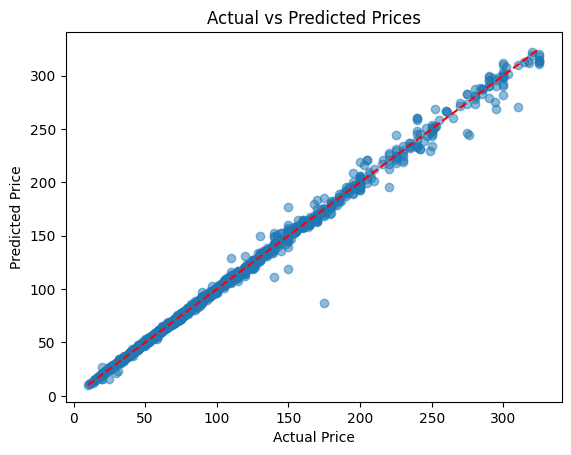

In [15]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()